<a href="https://colab.research.google.com/github/Afrid-40/Big-Market-Sales-Prediction/blob/main/big_market_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
sns.set_style("whitegrid")
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('bigmarket.csv')
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
df.shape

(8523, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


In [8]:
df['Item_Weight'].mean()

np.float64(12.857645184135976)

In [9]:
df['Item_Weight'].fillna(df['Item_Weight'].mean(), inplace = True)

In [10]:
df['Outlet_Size'].mode()

,Outlet_Size
0,Medium


In [11]:
mode_of_Outlet_size = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))

In [12]:
print(mode_of_Outlet_size)

Outlet_Type Grocery Store Supermarket Type1 Supermarket Type2  \
Outlet_Size         Small             Small            Medium   

Outlet_Type Supermarket Type3  
Outlet_Size            Medium  


In [13]:
miss_values = df['Outlet_Size'].isnull()

In [14]:
print(miss_values)

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool


In [15]:
df.loc[miss_values, 'Outlet_Size'] = df.loc[miss_values, 'Outlet_Type'].apply(lambda x:mode_of_Outlet_size[x])

In [16]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [17]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.226124,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,9.310000,0.026989,93.826500,1987.000000,834.247400
50%,12.857645,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


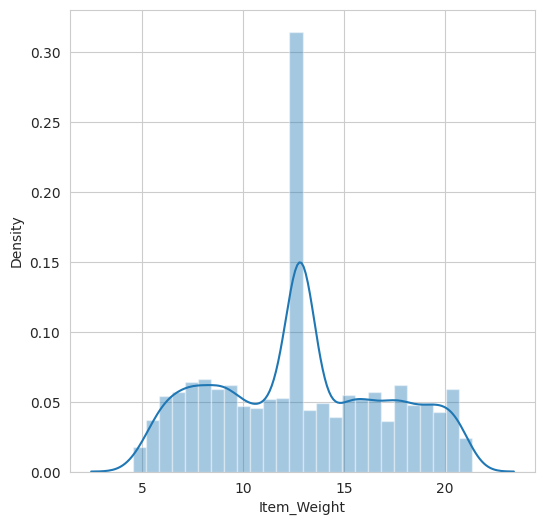

In [18]:
plt.figure(figsize=(6,6))
sns.distplot(df['Item_Weight'])
plt.show()

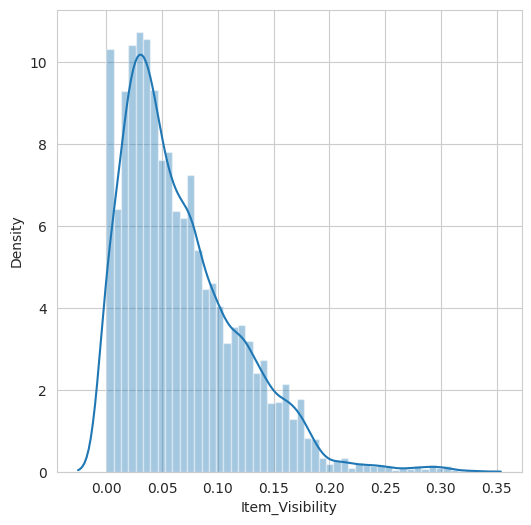

In [19]:
plt.figure(figsize=(6,6))
sns.distplot(df['Item_Visibility'])
plt.show()

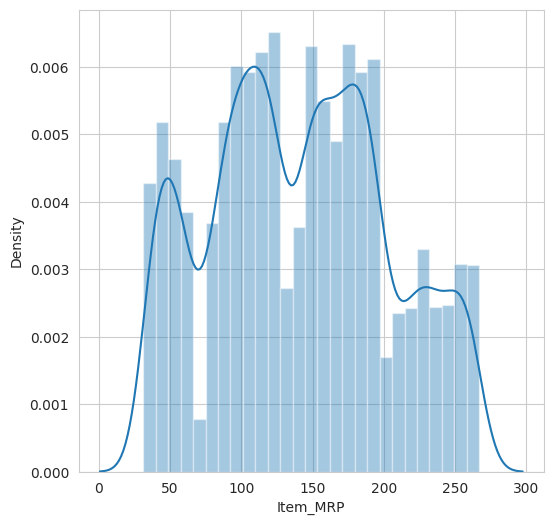

In [20]:
plt.figure(figsize=(6,6))
sns.distplot(df['Item_MRP'])
plt.show()

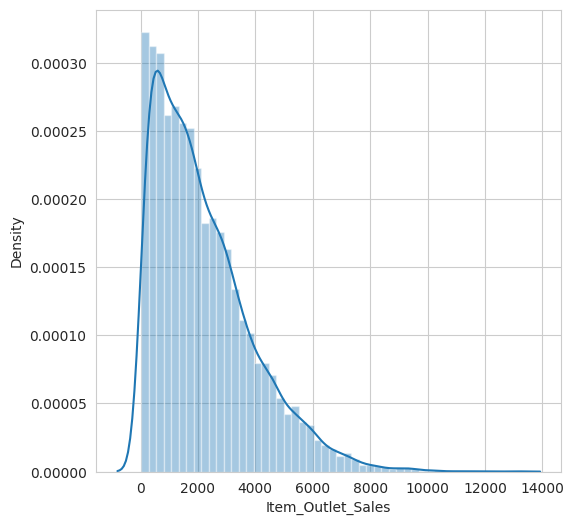

In [21]:
plt.figure(figsize=(6,6))
sns.distplot(df['Item_Outlet_Sales'])
plt.show()

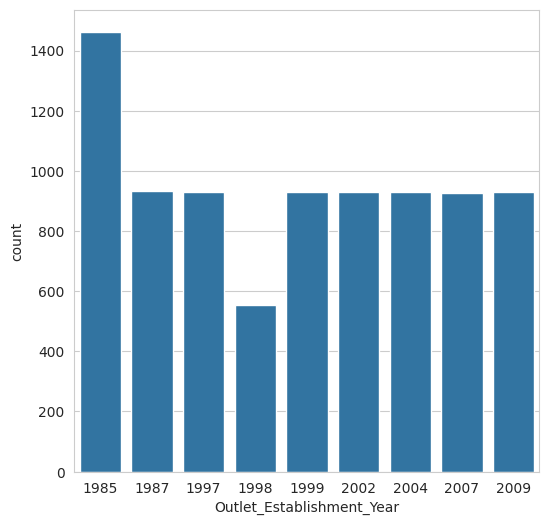

In [22]:
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Establishment_Year', data=df)
plt.show()

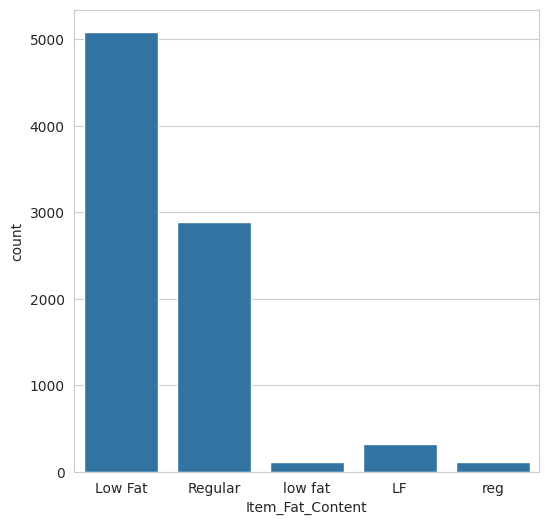

In [23]:
plt.figure(figsize=(6,6))
sns.countplot(x='Item_Fat_Content', data=df)
plt.show()

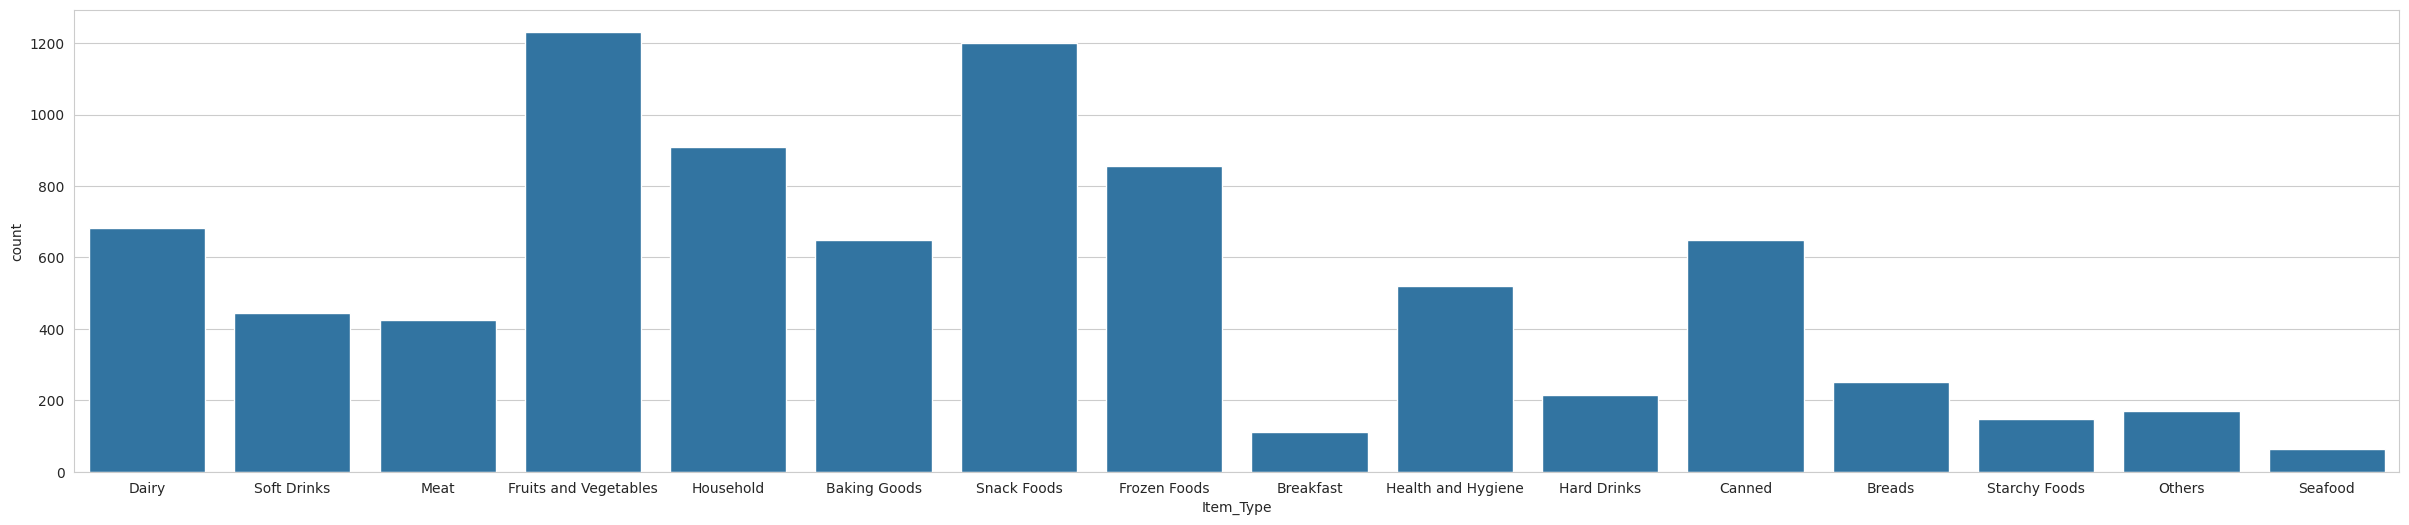

In [24]:
plt.figure(figsize=(30,6))
sns.countplot(x='Item_Type', data=df)
plt.show()

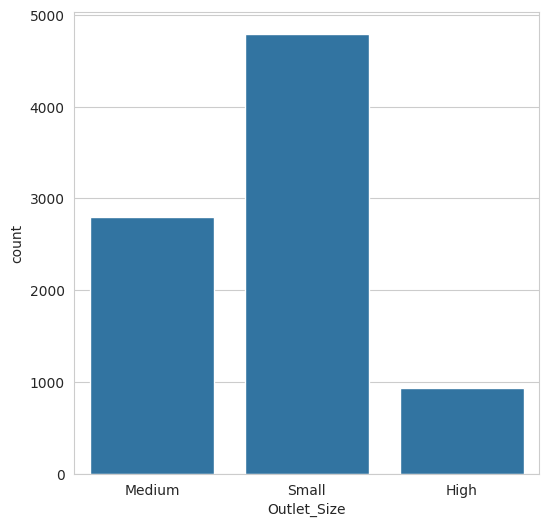

In [25]:
plt.figure(figsize=(6,6))
sns.countplot(x='Outlet_Size', data=df)
plt.show()

In [26]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [27]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5089
Regular,2889
LF,316
reg,117
low fat,112


In [28]:
df.replace({'Item_Fat_Content':{'low fat':'Low Fat', 'LF':'Low Fat', 'reg':'Regular'}},inplace=True)

In [29]:
df['Item_Fat_Content'].value_counts()

,count
Item_Fat_Content,
Low Fat,5517
Regular,3006


In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
encoder = LabelEncoder()

In [32]:
df['Item_Identifier'] = encoder.fit_transform(df['Item_Identifier'])

df['Item_Fat_Content'] = encoder.fit_transform(df['Item_Fat_Content'])

df['Item_Type'] = encoder.fit_transform(df['Item_Type'])

df['Outlet_Identifier'] = encoder.fit_transform(df['Outlet_Identifier'])

df['Outlet_Size'] = encoder.fit_transform(df['Outlet_Size'])

df['Outlet_Location_Type'] = encoder.fit_transform(df['Outlet_Location_Type'])

df['Outlet_Type'] = encoder.fit_transform(df['Outlet_Type'])

In [33]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,156,9.30,0,0.016047,4,249.8092,9,1999,1,0,1,3735.1380
1,8,5.92,1,0.019278,14,48.2692,3,2009,1,2,2,443.4228
2,662,17.50,0,0.016760,10,141.6180,9,1999,1,0,1,2097.2700
3,1121,19.20,1,0.000000,6,182.0950,0,1998,2,2,0,732.3800
4,1297,8.93,0,0.000000,9,53.8614,1,1987,0,2,1,994.7052


In [34]:
X = df.iloc[:,:-1].values
y = df.iloc[:,-1].values

In [35]:
print(X)

[[1.560e+02 9.300e+00 0.000e+00 ... 1.000e+00 0.000e+00 1.000e+00]
 [8.000e+00 5.920e+00 1.000e+00 ... 1.000e+00 2.000e+00 2.000e+00]
 [6.620e+02 1.750e+01 0.000e+00 ... 1.000e+00 0.000e+00 1.000e+00]
 ...
 [1.357e+03 1.060e+01 0.000e+00 ... 2.000e+00 1.000e+00 1.000e+00]
 [6.810e+02 7.210e+00 1.000e+00 ... 1.000e+00 2.000e+00 2.000e+00]
 [5.000e+01 1.480e+01 0.000e+00 ... 2.000e+00 0.000e+00 1.000e+00]]


In [36]:
print(y)

[3735.138   443.4228 2097.27   ... 1193.1136 1845.5976  765.67  ]


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=0)

In [38]:
print(X.shape, X_train.shape, X_test.shape)

(8523, 11) (6818, 11) (1705, 11)


In [39]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [40]:
model = Sequential()

model.add(Dense(20, activation='relu'))
model.add(Dense(10, activation='relu'))
model.add(Dense(5, activation='relu'))

model.add(Dense(1)) # output layer

model.compile(optimizer='rmsprop', loss='mse')

In [41]:
model.fit(x = X_train, y = y_train, epochs=50)

Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 5033387.5000
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2853574.7500
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2787278.7500
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2719252.5000
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2639877.5000
Epoch 6/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2550132.5000
Epoch 7/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2442289.7500
Epoch 8/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2325355.7500
Epoch 9/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2200570.2500
Epoch 10/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2086171.2500
Epoch 11/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 2002954.3750
Epoch 12/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 1955291.7500
Epoch 13/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1937160.1250
Epoch 14/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,024 (4.00 KB)

 Trainable params: 511 (2.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 513 (2.01 KB)

In [43]:
loss_df = pd.DataFrame(model.history.history)

In [44]:
loss_df

,loss
0,5033387.500
1,2853574.750
2,2787278.750
3,2719252.500
4,2639877.500
5,2550132.500
6,2442289.750
7,2325355.750
8,2200570.250
9,2086171.250


<Axes: >

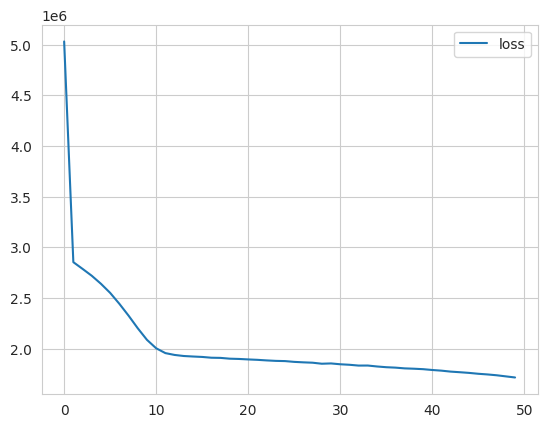

In [45]:
loss_df.plot()

In [46]:
test_eval = model.evaluate(X_test, y_test, verbose=0)
print(test_eval)

1741857.125


In [47]:
train_eval = model.evaluate(X_train, y_train, verbose=0)
print(train_eval)

1717237.625


In [48]:
model_diff = train_eval - test_eval
print(model_diff)

-24619.5


In [49]:
train_prediction = model.predict(X_train)

214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [50]:
test_prediction = model.predict(X_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [51]:
print(train_prediction)

[[2396.6611]
 [ 877.9931]
 [1067.579 ]
 ...
 [1288.5388]
 [2049.9976]
 [3219.6997]]


In [52]:
print(test_prediction)

[[2738.5066]
 [1424.4817]
 [1868.5212]
 ...
 [4172.4624]
 [ 534.7643]
 [4502.845 ]]


In [53]:
from sklearn.metrics import r2_score
r2_train = r2_score(y_train, train_prediction)

In [54]:
print('R squared value of train data:', r2_train)

R squared value of train data: 0.4094794697249078


In [55]:
r2_test = r2_score(y_test, test_prediction)

In [56]:
print('R squared value of test data:',r2_test)

R squared value of test data: 0.4048715021249396
